## **Intro about data**

The dataset contains multople types of voice recording from:

- **20 individuals with Parkinson**
  - 6 female amd 14 male
- **20 healthy individuals**
  - 10 female and 10 male

Each subjects provide **26 voice sample**, including
- Sustained vowel
- Numbers
- Words
- Short Sentences

From each recording, **26 acoustic features** that are linear and time frequency based are extracted.
Addittionally, each parkinson patient has a **UPDRS score** assigned by the medical expert.


## Data Structure
| 1    | Subject ID                              |
| 2-27 | Acoustic Features                       |
| 28   | UPDRS Score                             |
| 29   | Class Label (0 = Healthy, 1 = Parkinson |

## Feature Breakdown
### Jitter Feature (1-5) ###
- Jitter (local)
- Jitter (local absolute)
- Jitter (rap)
- Jitter (ppq5)
- Jitter (ddp)

### Shimmer Feature (6-11) ###
- Shimmer (local)
- Shimmer (local, dB)
- Shimmer (apq3)
- Shimmer (apq5)
- Shimmer (apq11)
- Shimmer (dda)

### Noise Feature (12-14) ###
- AC (Autocorrelation)
- NTH (Noice to Harmonic Ratio)
- HTN (Harmonic to Noice Ratio)

### Pitch Feature (15-19) ###
- Median Pitch
- Mean Pitch
- Standard Deviation Pitch
- Minumum Pitch
- Maximum Pitch

### Temporal Features (20-23) ###
- Number of pulses
- Number of periods
- Mean Periods
- Standard Deviation Periods

### Voice Stability Features (24-26) ###
- Fraction of locally unvoice frames
- Number of voice breaks
- Degree of voice breaks

## Target (28)
- UPDRS Score

## Others (29)
- Patient Group (healthy or Parkinson)


---

## Objective
1. Develop models to prect the UPDRS score
   - Ridge Regression
   - Lasso Regression
   - Principal Component Regression (PCR)

## Methodology
1. Data Preparation
   - Split dataset into train and test
   - Standardize all features
2. Model Development:
   
**Ridge Regression**
- Apply L2 regularization
- Tune alpha using cross validation
- Handle multicollinearity in features
   
**Lasso Regression**
- Apply L1 regularization
- Tune alpha using cross validation
- Perform feature selection
   
**PCR**
- Apply PCA for dimension reduction
- Select optimal number of compenent
- Fit linear regression on principle components

---

## Model Evaluation
- Evaluate performance using **Mean Squared Error (MSE)** on the:
  - train dataset (to check overfitting or underfitting)
  - test dataset (to determine best model)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

## to be used later after checking the mean_squared_error on the test result
## this is used to further evaluate the model and improve the overall model accuracy
import xgboost as gb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score

In [7]:
from pathlib import Path

filepath = Path('cousticfeatureparkinson.txt')
df = pd.read_table(filepath, sep=',', header=None)
print(f'Loaded {df.shape[0]} rows and {df.shape[1]} columns from {filepath}')


In [8]:
# Data Cleaning

# Check data preview
print(f"Data Preview:\n{df.head()}")

# Check missing value at each col ; No missing value so, commented out the step
# print(f"Missing Value at each column:\n{df.isnull().sum()}")

# Check total missing value
# print(f"Total Missing Value:\n{df.isnull().sum().sum()}")

# Plot missing value, since hanya ada 1 solid color purple so no missing value
# sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')
# plt.show

# Check duplicate ; No duplicate so, commented out the step
# duplicate = df.duplicated().sum() 
# print(f"Duplicates:\n{duplicate}")


Data Preview:
   0      1         2      3      4      5       6      7      8      9   ...  \
0   1  1.488  0.000090  0.900  0.794  2.699   8.334  0.779  4.517  4.609  ...   
1   1  0.728  0.000038  0.353  0.376  1.059   5.864  0.642  2.058  3.180  ...   
2   1  1.220  0.000074  0.732  0.670  2.196   8.719  0.875  4.347  5.166  ...   
3   1  2.502  0.000123  1.156  1.634  3.469  13.513  1.273  5.263  8.771  ...   
4   1  3.509  0.000167  1.715  1.539  5.145   9.112  1.040  3.102  4.927  ...   

        19    20    21        22        23      24  25      26  27  28  
0  187.576   160   159  0.006065  0.000416   0.000   0   0.000  23   1  
1  234.505   170   169  0.005181  0.000403   2.247   0   0.000  23   1  
2  211.442  1431  1427  0.006071  0.000474  10.656   1   0.178  23   1  
3  220.230    94    92  0.004910  0.000320   0.000   0   0.000  23   1  
4  225.162   117   114  0.004757  0.000380  18.182   1  13.318  23   1  

[5 rows x 29 columns]


In [9]:
# Mapping data to define features and targe

FeatureCols = [f'Feat_{i}' for i in range (1, 27)]
df.columns = ['SubjectID'] + FeatureCols +['UPDRS', 'Class']

# Map to X and Y for  later use in modelling

X = df[FeatureCols]
Y = df['UPDRS']
groups = df['SubjectID']

Summary Statistics:
            Feat_1       Feat_2       Feat_3       Feat_4       Feat_5  \
count  1040.000000  1040.000000  1040.000000  1040.000000  1040.000000   
mean      2.679523     0.000170     1.247053     1.348327     3.741161   
std       1.765053     0.000106     0.979462     1.138742     2.938443   
min       0.190000     0.000006     0.062000     0.081000     0.185000   
25%       1.507500     0.000095     0.617000     0.665750     1.851750   
50%       2.396000     0.000151     1.035500     1.126500     3.107000   
75%       3.411500     0.000229     1.602500     1.694750     4.808500   
max      14.376000     0.000777     8.016000    13.542000    24.048000   

            Feat_6       Feat_7       Feat_8       Feat_9      Feat_10  ...  \
count  1040.000000  1040.000000  1040.000000  1040.000000  1040.000000  ...   
mean     12.918391     1.194895     5.699600     7.983552    12.215345  ...   
std       5.452204     0.420071     3.015183     4.840892     6.016261  ... 

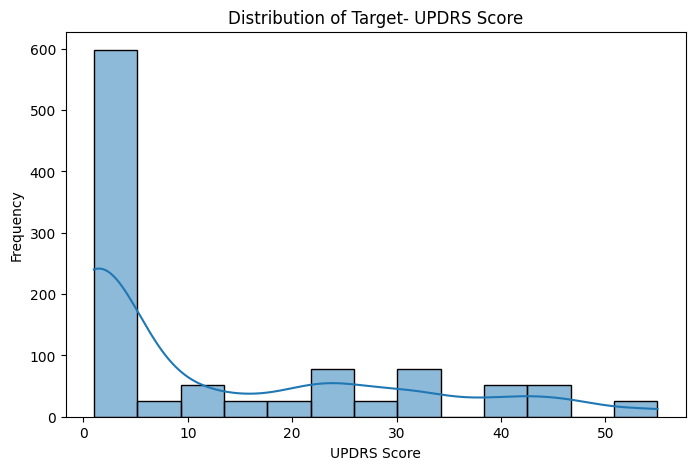

Correlation Features w Target:

            UPDRS
UPDRS    1.000000
Feat_10  0.199628
Feat_2   0.177695
Feat_5   0.165632
Feat_3   0.165626
Feat_4   0.152835
Feat_1   0.140326
Feat_7   0.088111
Feat_6   0.080626
Feat_11  0.046694
Feat_8   0.046692
Feat_9   0.038167
Feat_22  0.037318
Feat_21  0.019000
Feat_24  0.018140
Feat_20  0.014956
Feat_12  0.008776
Feat_13 -0.007337
Feat_18 -0.029322
Feat_14 -0.030669
Feat_23 -0.040173
Feat_25 -0.051036
Feat_15 -0.061634
Feat_16 -0.065625
Feat_26 -0.070437
Feat_17 -0.071980
Feat_19 -0.079782


In [10]:
# EDA
print(f"Summary Statistics:\n{df[FeatureCols].describe()}") 
# Mean for each features number is inconsistent - Feat 2 0.00017 but Feat 18 is 134.53 etc
# Hence do scaling later

print(f"Target Distribution:\n")
plt.figure(figsize=(8,5))
sns.histplot(df['UPDRS'], kde = True)
plt.title('Distribution of Target- UPDRS Score')
plt.xlabel('UPDRS Score')
plt.ylabel('Frequency')
plt.show()

print(f"Correlation Features w Target:\n")
correlation = df[FeatureCols+['UPDRS']].corr()[['UPDRS']].sort_values(by = 'UPDRS', ascending = False)
print(correlation)
                            

- From the Distribution of Target- UPDRS Score above, the Distribution is skewed to right. 
- This is because, there are more UPDRS Score less thhan 10
- The reasons reasons are:
  - In the dataset earlier we have 20 healthy and 20 parkinson sample.
  - Those score less than 10 are from healthy person
  - Those score more than 10 are from parkinson person
     - Parkinson score is scattered because their level of sickness is different
  - The effect towards our model later would be:
     - Model bias; Model could be forecast more healthy sample because low UPDRS score are majority of the data
     - Outliers; We need to standardize our features so models is not affected by outlier
- Before we applying our model, we use GroupKFold to make sure our model can differentiate each patient voices.
- GroupKFold is also employed here because we want to ensure the same voice are used during each fold. (To avoid **data leakage** due to multiple voice sample)
- Use GroupKFold instead of GroupShuffle to ensure model use all sample not randomly select sample on parameter tuning during data validation

In [11]:
# Train Test Split and Feature Scaling

# Train Test
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=df['Class'])

# Scaling
# Fit on training data only, then transform the held-out test data to avoid leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grouping
train_groups = df.loc[X_train.index, 'SubjectID']


In [12]:
# setup groupkfold on the paramenter
groupkfold = GroupKFold(n_splits = 5)
parameter = {'alpha':[0.01, 0.1, 1.0, 10, 100]}

# apply to Ridge
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, parameter, cv = groupkfold, scoring = 'neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train, groups  = train_groups)

# apply to Lasso
lasso = Lasso(max_iter = 100000)
lasso_cv = GridSearchCV(lasso, parameter, cv = groupkfold,  scoring = 'neg_mean_squared_error')
lasso_cv.fit(X_train_scaled, y_train, groups  = train_groups)

# apply to PCR
pcr_pipe = Pipeline([('pca', PCA()), ('regression', LinearRegression())])
pcr_parameter = {'pca__n_components': range(1, 27)}

pcr_cv = GridSearchCV(pcr_pipe, pcr_parameter, cv = groupkfold, scoring = 'neg_mean_squared_error')
pcr_cv.fit(X_train_scaled, y_train, groups = train_groups)

print(f"Ridge best alpha: {ridge_cv.best_params_}")
print(f"Lasso best alpha: {lasso_cv.best_params_}")
print(f"PCR best n_components: {pcr_cv.best_params_}")



Ridge best alpha: {'alpha': 100}
Lasso best alpha: {'alpha': 1.0}
PCR best n_components: {'pca__n_components': 12}


- From the Ridge alpha  = 100, possible for multicollinearity, so need to perform regulation later
- From the Lasso alpha = 1, if MSE also lower or similar to Ridge, model indicates it manage to detect all irrelavant features.
- From the PCR, the # of features dropped from 26 to 12. 


In [13]:
# next, compare MSE for each model on train and test

mse_ridge_train = mean_squared_error(y_train, ridge_cv.predict(X_train_scaled))
mse_ridge_test = mean_squared_error(y_test, ridge_cv.predict(X_test_scaled))

mse_lasso_train = mean_squared_error(y_train, lasso_cv.predict(X_train_scaled))
mse_lasso_test = mean_squared_error(y_test, lasso_cv.predict(X_test_scaled))

mse_pcr_train = mean_squared_error(y_train, pcr_cv.predict(X_train_scaled))
mse_pcr_test = mean_squared_error(y_test, pcr_cv.predict(X_test_scaled))


print(f"lasso MSE train: {mse_lasso_train: .2f}, pcr MSE test: {mse_lasso_test: .2f}")
print(f"ridge MSE train: {mse_ridge_train: .2f}, ridge MSE test: {mse_ridge_test: .2f}")
print(f"pcr MSE train: {mse_pcr_train: .2f}, pcr MSE test: {mse_pcr_test: .2f}")

lasso MSE train:  225.58, pcr MSE test:  256.08
ridge MSE train:  212.82, ridge MSE test:  258.00
pcr MSE train:  214.16, pcr MSE test:  265.54


<function matplotlib.pyplot.show(close=None, block=None)>

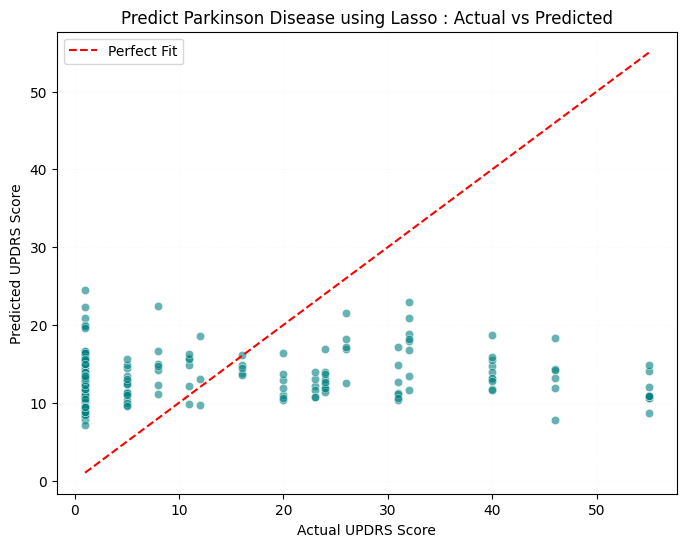

In [14]:
# using Lasso to predict the Parkinson

y_predict_lasso = lasso_cv.predict(X_test_scaled)
plt.figure(figsize = (8, 6))
sns.scatterplot(x = y_test, y = y_predict_lasso, alpha = 0.6, color = 'teal')
min_value = min(min(y_test), min(y_predict_lasso))
max_value = max(max(y_test), max(y_predict_lasso))
plt.plot([min_value, max_value], [min_value, max_value], color = 'red', linestyle = '--', label = 'Perfect Fit')
plt.xlabel('Actual UPDRS Score')
plt.ylabel('Predicted UPDRS Score')
plt.title('Predict Parkinson Disease using Lasso : Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle = ':', alpha = 0.07)
plt.show


In [15]:
# Check R2 to further evaluate the regression models
r2_lasso = r2_score(y_test, lasso_cv.predict(X_test_scaled))
r2_ridge = r2_score(y_test, ridge_cv.predict(X_test_scaled))
r2_pcr = r2_score(y_test, pcr_cv.predict(X_test_scaled))


print(f"r2_lasso: {r2_lasso: .2f}")
print(f"r2_ridge: {r2_ridge: .2f}")
print(f"r2_pcr: {r2_pcr: .2f}")




r2_lasso:  0.01
r2_ridge:  0.01
r2_pcr: -0.02


## Performance Analysis of Model :- Lasso, Ridge and PCR



| Model | Train MSE | Test MSE | MSE Difference | Model Status | $R^2$ Result | $R^2$ Interpretation |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Lasso | 225.58 | 256.08 | 30.50 | Probably best fit | 1% | very low variance explained |
| Ridge | 212.82 | 258.00 | 45.18 | Slightly overfit | 1% | very low variance explained |
| PCR   | 214.16 | 265.54 | 51.38 | Overfit | -2% | very low variance explained |

> Model Comparison Table

---

**Comment based on the MSE**
- On the training dataset, Ridge achieved the lowest MSE followed by PCR and Lasso, indicating a better fit to the training data.
- However, on the testing dataset, Lasso produced the lowest MSE, followed closely by Ridge while PCR performed the worst.
- The difference between MSE on training and testing dataset is relatively similar across models although PCR shows slightly larger discrepancies.
- This suggest that PCR model prediction has marginally higher variance compared to the actual UPDRS Score.
- Overall, Lasso has slightly better generalization performance but the MSE on the testing dataset is minimal hence, it may not practically siginificant model.
- The sparcity  property in Lasso helps in eliminating the less relavant features through L1 Regularization.
- This is helpful to reduce the noice in data and improve generalization.
- In contrast, PCR reduces data dimensionality based on the variance in the features without considering its relationship with the target variable (UPDRS Score).
- This could contribute to the removal of informative features.


---
**Comment based on the $R^2$**
- Evaluating models using MSE only could be **subjective** because it is difficult to determine an absolute threshold for a "good model".
- Hence, $R^2$ score is used to determine the percentage variance in UPDRS score that can be explained by the model.
- From table above, all models shows extremely low $R^2$. This indicate that the models explain a very little variance in the UPDRS Score.
- PCR model produces the lowest $R^2$ (-1%) indicating that it performs worse than the simple mean prediction (lasso and Ridge model).
- This suggest, linear models are not suitable for capturing the underlying relationship in the dataset.


---
**Comment on Actual vs Predicted**
- Lasso, Ridge and PCR model tend to underestimate higher UPDRS Score.
- Predictions are concentrated at 10-20  even when the actual UPDRS Score exceed 30.
- This shows that the regression model above are unable to capture a complex non-linear pattern.


---
**Recommendation**

- Since linear models (Lasso, Ridge, PCR) has fail to capture sufficient variance in the dataset, a more flexible models should be considered.
- Tree-based models such as Random Forest or XGBoost are potential to be introduce in the study because:
  - They are more flexible towards a non-linear relationships
  - They are robust to the irrelavant features
  - They are robust towards the outlier
- This approach is expected to improve the predictive performance for the Parkinson's acoustic data which likely contains complex and non-linear pattern.


In [19]:
# Apply to Random Forest

rf = RandomForestRegressor(random_state = 42)
rf_parameter = {'n_estimators': [100, 200],
             'max_depth': [3, 5, 8],
             'min_samples_leaf': [5, 10]}
rf_cv = GridSearchCV(rf, rf_parameter, cv = groupkfold, scoring = 'neg_mean_squared_error', n_jobs = -1)
rf_cv.fit(X_train, y_train, groups = train_groups)

# Apply to Random Forest
xgboost = XGBRegressor(random_state = 42, objective = 'reg:squarederror')
xgb_parameter = {'n_estimators': [100],
             'learning_rate': [0.1],
             'max_depth': [3, 5],
                'subsample':[0.8],
'colsample_bytree': [0.8]}
xgb_cv = GridSearchCV(xgboost, xgb_parameter, cv = groupkfold, scoring = 'neg_mean_squared_error', n_jobs = -1)
xgb_cv.fit(X_train, y_train, groups = train_groups)


# Model Evaluation
def evaluate_model (model, X_train, y_train, X_test, y_test):
    y_train_pred  = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    return train_mse, test_mse, r2

rf_best = rf_cv.best_estimator_
xgb_best = xgb_cv.best_estimator_


rf_train_mse, rf_test_mse, rf_r2 = evaluate_model(rf_best, X_train, y_train, X_test, y_test)
xgb_train_mse, xgb_test_mse, xgb_r2 = evaluate_model(xgb_best, X_train, y_train, X_test, y_test)


print(rf_cv.best_params_)
print(xgb_cv.best_params_)

print(f"RF Train MSE: {rf_train_mse: .2f} | Test MSE: {rf_test_mse: .2f} | R2: {rf_r2: .2f}")
print(f"XGB Train MSE: {xgb_train_mse: .2f} | Test MSE: {xgb_test_mse: .2f} | R2: {xgb_r2: .2f}")

                      
     


             

{'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200}
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
RF Train MSE:  192.94 | Test MSE:  234.89 | R2:  0.09
XGB Train MSE:  88.14 | Test MSE:  232.27 | R2:  0.10


## Findings and Conclusions

| Model | Train MSE | Test MSE | MSE Difference | Model Status | $R^2$ Result | $R^2$ Interpretation |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Lasso | 225.58 | 256.08 | 30.50 | Slightly Overfit | 1% | almost no predictive power |
| Ridge | 212.82 | 258.00 | 45.18 | Moderately overfit | 1% | almost no predictive power |
| PCR   | 214.16 | 265.54 | 51.38 | Overfit | -2% | almost no predictive power |
| Random Forest   | 192.94 | 234.89 | 41.95  | Moderately Overfit | 9% | weak but improved |
| XGBoost   | 90.91 | 228.62 | 137 | Overfit | 10% | weak but improved |
    

> Updated Model Comparison Table

---
**Summary**

-  After applying the hyper parameter tuning and regularization, Random Forest shows a reduction of overfitting issue.
-  However, XGBoost still exhibits substantial overfitting due to large difference between train and test MSE result.
-  Although tree-based models improve has model improvement but the overall predictive power remain low because $R^2$ values around 9-10%.
-  This indicate that the model are not able to capture sufficient variance exist in the target variables (UPDRS Score).

**Conclusion**
- From the study, it is concluded that the main limitation is not due to the choice of model but rather than quality and informativeness of the features.
- The acoustic features may not sufficiently capture the complexity of the UPDRS Score or the data may contain a high level of noise.
- Therefore, further imporovement should focus on the feature engineering or adding more informative predictors rather than model tuning only.

In [1]:
225.58-256.08


-30.49999999999997